# VDA Report Explorer
Inspect the raw `theta_hat` matrices saved in `data/reports/` and summarize results.

In [9]:
import numpy as np
import json
from pathlib import Path

SUBSET = "Hand-Crafted"
REPORT_DIR = Path("data/reports") / SUBSET

manifest = json.load(open(REPORT_DIR / "manifest.json"))
report_files = sorted(REPORT_DIR.glob("*.npz"), key=lambda f: int(f.stem))

print(f"Model      : {manifest['model']}")
print(f"Temperatures: {manifest['temperatures']}")
print(f"K          : {manifest['K']}")
print(f"Saved traces: {len(report_files)}")

Model      : gpt-4o-mini
Temperatures: [0.0, 0.7, 1.0]
K          : 3
Saved traces: 10


## 1. Raw data — pick a trace

In [10]:
TRACE_ID = 1   # change this to look at different traces

data = np.load(REPORT_DIR / f"{TRACE_ID}.npz", allow_pickle=True)
theta = data["theta_hat"]          # shape (K, T)
model_ids = list(data["model_ids"])
mistake_agent = str(data["mistake_agent"])
mistake_step  = int(data["mistake_step"])
K, T = theta.shape

print(f"Trace {TRACE_ID}")
print(f"  T (steps)     : {T}")
print(f"  mistake_agent : {mistake_agent}")
print(f"  mistake_step  : {mistake_step}  <- ground truth")
print(f"  model_ids     : {model_ids}")
print()
print("theta_hat raw (K x T):")
print("  rows = discriminators, columns = steps")
print(np.round(theta, 3))

Trace 1
  T (steps)     : 91
  mistake_agent : Orchestrator
  mistake_step  : 9  <- ground truth
  model_ids     : [np.str_('gpt-4o-mini@T=0.0'), np.str_('gpt-4o-mini@T=0.7'), np.str_('gpt-4o-mini@T=1.0')]

theta_hat raw (K x T):
  rows = discriminators, columns = steps
[[0.924 0.947 0.818 1.    0.991 0.967 1.    0.958 0.995 0.999 0.999 0.984
  0.986 0.995 0.971 0.867 0.996 0.996 0.932 0.893 0.98  0.982 0.867 0.651
  0.932 0.977 0.245 0.593 0.991 0.974 0.5   0.269 0.958 0.932 0.818 0.835
  0.988 0.982 0.893 0.755 0.995 0.995 0.469 0.407 0.997 0.998 0.852 0.378
  0.991 0.986 0.818 0.777 0.986 0.998 0.881 0.706 0.988 0.991 0.974 0.991
  0.998 0.997 0.974 0.932 0.984 0.989 0.977 0.963 0.893 0.998 0.867 0.777
  0.958 0.963 0.915 0.963 0.998 0.818 0.438 0.997 0.997 0.94  0.953 0.98
  0.988 0.99  0.953 0.995 1.    1.    0.993]
 [0.924 0.947 0.798 1.    0.989 0.963 0.999 0.967 0.995 0.999 0.999 0.99
  0.98  0.998 0.971 0.881 0.997 0.995 0.932 0.679 0.982 0.982 0.881 0.562
  0.963 0.989 0.469 

In [11]:
# Print as a readable table: step | D0 | D1 | D2 | mean | ground_truth?
print(f"{'step':>5} | {'D0':>6} | {'D1':>6} | {'D2':>6} | {'mean':>6} | GT")
print("-" * 48)
for t in range(T):
    vals = theta[:, t]
    gt = " <-- MISTAKE" if t == mistake_step else ""
    print(f"{t:>5} | {vals[0]:>6.3f} | {vals[1]:>6.3f} | {vals[2]:>6.3f} | {vals.mean():>6.3f} |{gt}")

 step |     D0 |     D1 |     D2 |   mean | GT
------------------------------------------------
    0 |  0.924 |  0.924 |  0.905 |  0.918 |
    1 |  0.947 |  0.947 |  0.963 |  0.952 |
    2 |  0.818 |  0.798 |  0.798 |  0.805 |
    3 |  1.000 |  1.000 |  0.999 |  1.000 |
    4 |  0.991 |  0.989 |  0.990 |  0.990 |
    5 |  0.967 |  0.963 |  0.963 |  0.964 |
    6 |  1.000 |  0.999 |  0.999 |  0.999 |
    7 |  0.958 |  0.967 |  0.947 |  0.957 |
    8 |  0.995 |  0.995 |  0.993 |  0.994 |
    9 |  0.999 |  0.999 |  0.995 |  0.998 | <-- MISTAKE
   10 |  0.999 |  0.999 |  1.000 |  0.999 |
   11 |  0.984 |  0.990 |  0.984 |  0.986 |
   12 |  0.986 |  0.980 |  0.994 |  0.987 |
   13 |  0.995 |  0.998 |  0.992 |  0.995 |
   14 |  0.971 |  0.971 |  0.971 |  0.971 |
   15 |  0.867 |  0.881 |  0.867 |  0.872 |
   16 |  0.996 |  0.997 |  0.998 |  0.997 |
   17 |  0.996 |  0.995 |  0.996 |  0.996 |
   18 |  0.932 |  0.932 |  0.932 |  0.932 |
   19 |  0.893 |  0.679 |  0.679 |  0.751 |
   20 |  0.9

## 2. Heatmap of theta_hat

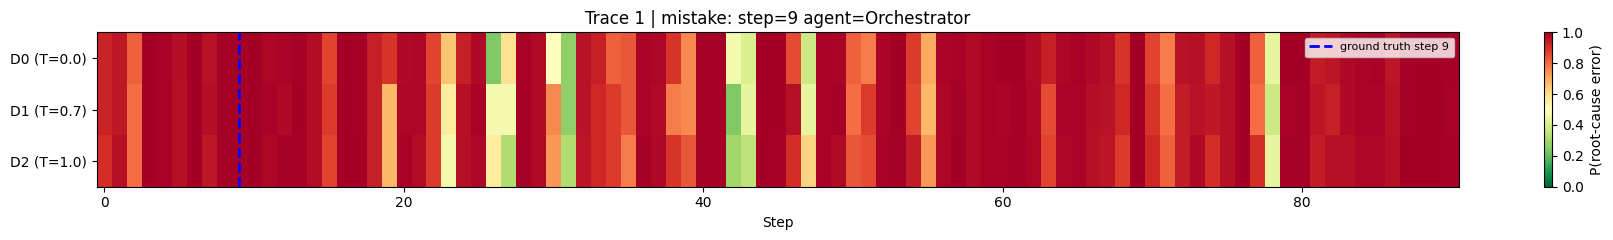

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(max(10, T * 0.2), 2.5))
im = ax.imshow(theta, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn_r")
plt.colorbar(im, ax=ax, label="P(root-cause error)")
ax.set_yticks(range(K))
ax.set_yticklabels([f"D{k} (T={manifest['temperatures'][k]})" for k in range(K)])
ax.set_xlabel("Step")
ax.set_title(f"Trace {TRACE_ID} | mistake: step={mistake_step} agent={mistake_agent}")
ax.axvline(mistake_step, color="blue", linewidth=2, linestyle="--", label=f"ground truth step {mistake_step}")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Mean probability per step

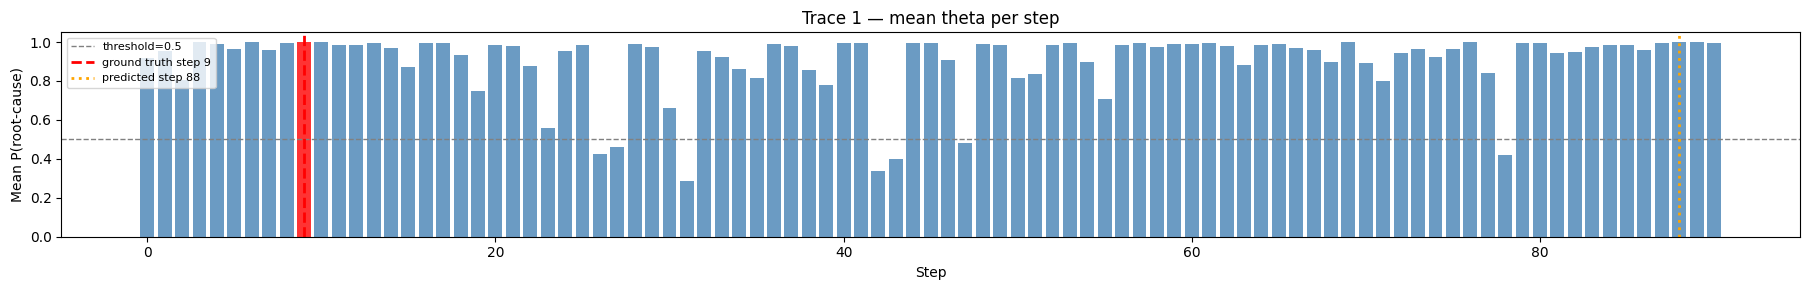

Predicted step : 88
Ground truth   : 9
Correct        : False


In [13]:
mean_theta = theta.mean(axis=0)
predicted_step = int(np.argmax(mean_theta))

fig, ax = plt.subplots(figsize=(max(10, T * 0.2), 3))
colors = ["red" if t == mistake_step else "steelblue" for t in range(T)]
ax.bar(range(T), mean_theta, color=colors, alpha=0.8)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="threshold=0.5")
ax.axvline(mistake_step, color="red", linewidth=2, linestyle="--", label=f"ground truth step {mistake_step}")
ax.axvline(predicted_step, color="orange", linewidth=2, linestyle=":", label=f"predicted step {predicted_step}")
ax.set_xlabel("Step")
ax.set_ylabel("Mean P(root-cause)")
ax.set_title(f"Trace {TRACE_ID} — mean theta per step")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Predicted step : {predicted_step}")
print(f"Ground truth   : {mistake_step}")
print(f"Correct        : {predicted_step == mistake_step}")

## 4. Summary across all saved traces

In [14]:
rows = []
for f in report_files:
    d = np.load(f, allow_pickle=True)
    th = d["theta_hat"]
    ms = int(d["mistake_step"])
    ma = str(d["mistake_agent"])
    mean_per_step = th.mean(axis=0)
    pred_step = int(np.argmax(mean_per_step))
    rows.append({
        "trace_id"       : int(f.stem),
        "T"              : th.shape[1],
        "mistake_agent"  : ma,
        "mistake_step"   : ms,
        "predicted_step" : pred_step,
        "step_correct"   : pred_step == ms,
        "mean_theta"     : round(float(mean_per_step.mean()), 4),
        "std_theta"      : round(float(mean_per_step.std()), 4),
        "min_theta"      : round(float(mean_per_step.min()), 4),
        "max_theta"      : round(float(mean_per_step.max()), 4),
    })

import pandas as pd
df = pd.DataFrame(rows)

acc = df["step_correct"].mean()
print(f"Acc_step (simple mean argmax): {acc:.2%}  ({df['step_correct'].sum()}/{len(df)} traces)")
print()
df

Acc_step (simple mean argmax): 10.00%  (1/10 traces)



,trace_id,T,mistake_agent,mistake_step,predicted_step,step_correct,mean_theta,std_theta,min_theta,max_theta
0,0,67,WebSurfer,3,12,False,0.9975,0.0054,0.9593,1.0000
1,1,91,Orchestrator,9,88,False,0.8986,0.1656,0.2862,1.0000
2,2,83,WebSurfer,8,16,False,0.9899,0.0171,0.9047,1.0000
3,3,21,Orchestrator,15,4,False,0.9861,0.0156,0.9466,0.9994
4,4,17,WebSurfer,12,6,False,0.9928,0.0071,0.9703,0.9997
5,5,8,Orchestrator,5,5,True,0.9279,0.0774,0.8037,1.0000
6,6,25,WebSurfer,8,4,False,0.9875,0.0449,0.7729,1.0000
7,7,129,WebSurfer,4,32,False,0.9859,0.0299,0.7222,1.0000
8,8,37,WebSurfer,8,28,False,0.9633,0.0665,0.6225,1.0000
9,9,17,WebSurfer,16,4,False,0.8988,0.2022,0.2427,0.9995


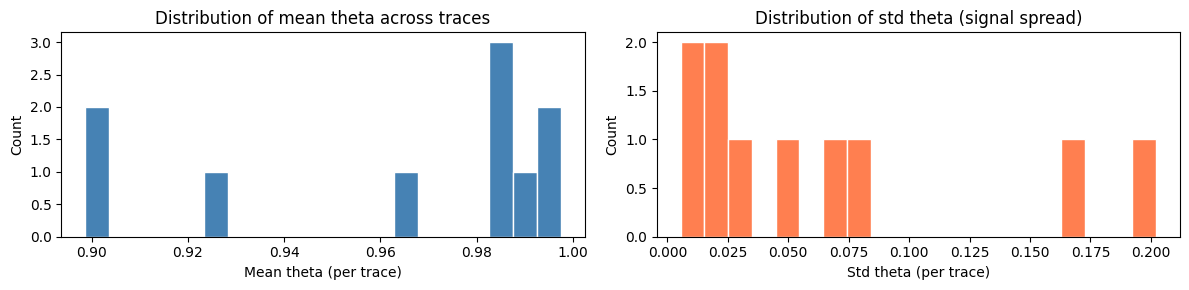

In [15]:
# Distribution of mean theta across all traces
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(df["mean_theta"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Mean theta (per trace)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of mean theta across traces")

axes[1].hist(df["std_theta"], bins=20, color="coral", edgecolor="white")
axes[1].set_xlabel("Std theta (per trace)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of std theta (signal spread)")

plt.tight_layout()
plt.show()